# SIH 2026 - Problem Statement SIH26168
# AI-ML Based Intelligent Dead Reckoning for Seamless Navigation
## Notebook 03: Vibration / Road-Noise Classification & Filtering Model

### Objective
Classify road vibration and mechanical disturbances (`smooth`, `moderate`, `high_vibration/shock`) from smartphone IMU signals to dynamically adapt sensor noise covariance in the dead reckoning navigation filter.

### Proxy Labeling Methodology
In the absence of physical road-profiler ground truth, proxy labels are mathematically derived from linear acceleration root-mean-square (RMS) and instantaneous jerk magnitude:
- **Smooth (0):** $	ext{RMS}(a_{	ext{linear}}) < 1.5	ext{ m/s}^2$
- **Moderate (1):** $1.5	ext{ m/s}^2 \le 	ext{RMS}(a_{	ext{linear}}) < 3.0	ext{ m/s}^2$
- **High Vibration / Shock (2):** $	ext{RMS}(a_{	ext{linear}}) \ge 3.0	ext{ m/s}^2$ OR $\max(|jerk|) > 15.0	ext{ m/s}^3$

In [1]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from common_utils import (
    MODELS_DIR, ARTIFACTS_DIR, FIGURES_DIR,
    compute_classification_metrics
)
import tensorflow as tf

print("Libraries loaded.")

I0000 00:00:1789132565.119015   67178 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132565.119396   67178 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789132565.153585   67178 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789132566.060968   67178 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132566.061190   67178 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries loaded.


### 1. Model Configuration & Metadata
Review the classification targets, class mapping, and feature columns.

In [2]:
meta_path = ARTIFACTS_DIR / "configs" / "vibration_model_metadata.json"
with open(meta_path) as f:
    vib_meta = json.load(f)

print(f"Model Name:        {vib_meta['model_name']}")
print(f"Architecture:      {vib_meta['model_architecture']}")
print(f"Class Mapping:     {vib_meta['class_mapping']}")
print(f"Thresholds:        {vib_meta['thresholds']}")
print(f"Parameters:        {vib_meta['n_parameters']:,}")
print(f"TFLite Size:       {vib_meta['model_size_kb']:.1f} KB")

Model Name:        vibration_classifier
Architecture:      1D-CNN (Conv1D(32) -> Conv1D(64) -> GAP -> Dense(32) -> Softmax)
Class Mapping:     {'0': 'smooth', '1': 'moderate', '2': 'high_vibration'}
Thresholds:        {'smooth_rms': 1.5, 'moderate_rms': 3.0, 'shock_jerk': 15.0}
Parameters:        9,379
TFLite Size:       20.5 KB


### 2. Deep Learning Architecture: 1D-CNN
A lightweight 1D-CNN with global average pooling (GAP) prevents overfitting and ensures zero-overhead edge conversion.

In [3]:
model_path = MODELS_DIR / "vibration" / "vibration_cnn.keras"
model = tf.keras.models.load_model(model_path)
model.summary()

E0000 00:00:1789132567.094681   67178 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "vibration_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 10, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vibration_output (Dense)        │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,755 (108.42 KB)

 Trainable params: 9,187 (35.89 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 18,376 (71.79 KB)

### 3. Classification Performance & Baseline Comparison
Compare the 1D-CNN against Rule-based thresholding and a Random Forest classifier.

In [4]:
cnn_m = vib_meta['metrics']['cnn']
rf_m = vib_meta['metrics']['random_forest']
rule_m = vib_meta['metrics']['rule_based']

comparison = [
    {'Model': 'Rule-Based Heuristic', 'Accuracy': rule_m['accuracy'], 'Precision': rule_m['precision'], 'Recall': rule_m['recall'], 'Macro F1': rule_m['f1']},
    {'Model': 'Random Forest', 'Accuracy': rf_m['accuracy'], 'Precision': rf_m['precision'], 'Recall': rf_m['recall'], 'Macro F1': rf_m['f1']},
    {'Model': '1D-CNN (Ours)', 'Accuracy': cnn_m['accuracy'], 'Precision': cnn_m['precision'], 'Recall': cnn_m['recall'], 'Macro F1': cnn_m['f1']}
]
display(pd.DataFrame(comparison))

,Model,Accuracy,Precision,Recall,Macro F1
0,Rule-Based Heuristic,0.652349,0.691632,0.652349,0.613885
1,Random Forest,0.976946,0.977027,0.976946,0.976935
2,1D-CNN (Ours),0.970599,0.971070,0.970599,0.970663


### 4. Per-Class Precision, Recall, and Confusion Matrix
Verify balanced classification across all three road vibration tiers.

In [5]:
report = cnn_m['report']
per_class = []
for cls_name in ['smooth', 'moderate', 'high_vibration']:
    if cls_name in report:
        per_class.append({
            'Class': cls_name,
            'Precision': report[cls_name]['precision'],
            'Recall': report[cls_name]['recall'],
            'F1-Score': report[cls_name]['f1-score'],
            'Support': int(report[cls_name]['support'])
        })
display(pd.DataFrame(per_class))

cm = np.array(cnn_m['confusion_matrix'])
classes = ['smooth', 'moderate', 'high_vibration']
cm_df = pd.DataFrame(cm, index=[f"True: {c}" for c in classes], columns=[f"Pred: {c}" for c in classes])
print("\nConfusion Matrix:")
display(cm_df)

,Class,Precision,Recall,F1-Score,Support
0,smooth,0.991550,0.961728,0.976412,25136
1,moderate,0.954850,0.979328,0.966934,25590
2,high_vibration,0.957893,0.970546,0.964178,7571



Confusion Matrix:


,Pred: smooth,Pred: moderate,Pred: high_vibration
True: smooth,24174,962,0
True: moderate,206,25061,323
True: high_vibration,0,223,7348


### 5. Empirical Performance Plots
Confusion matrix, class distribution across splits, and training history.

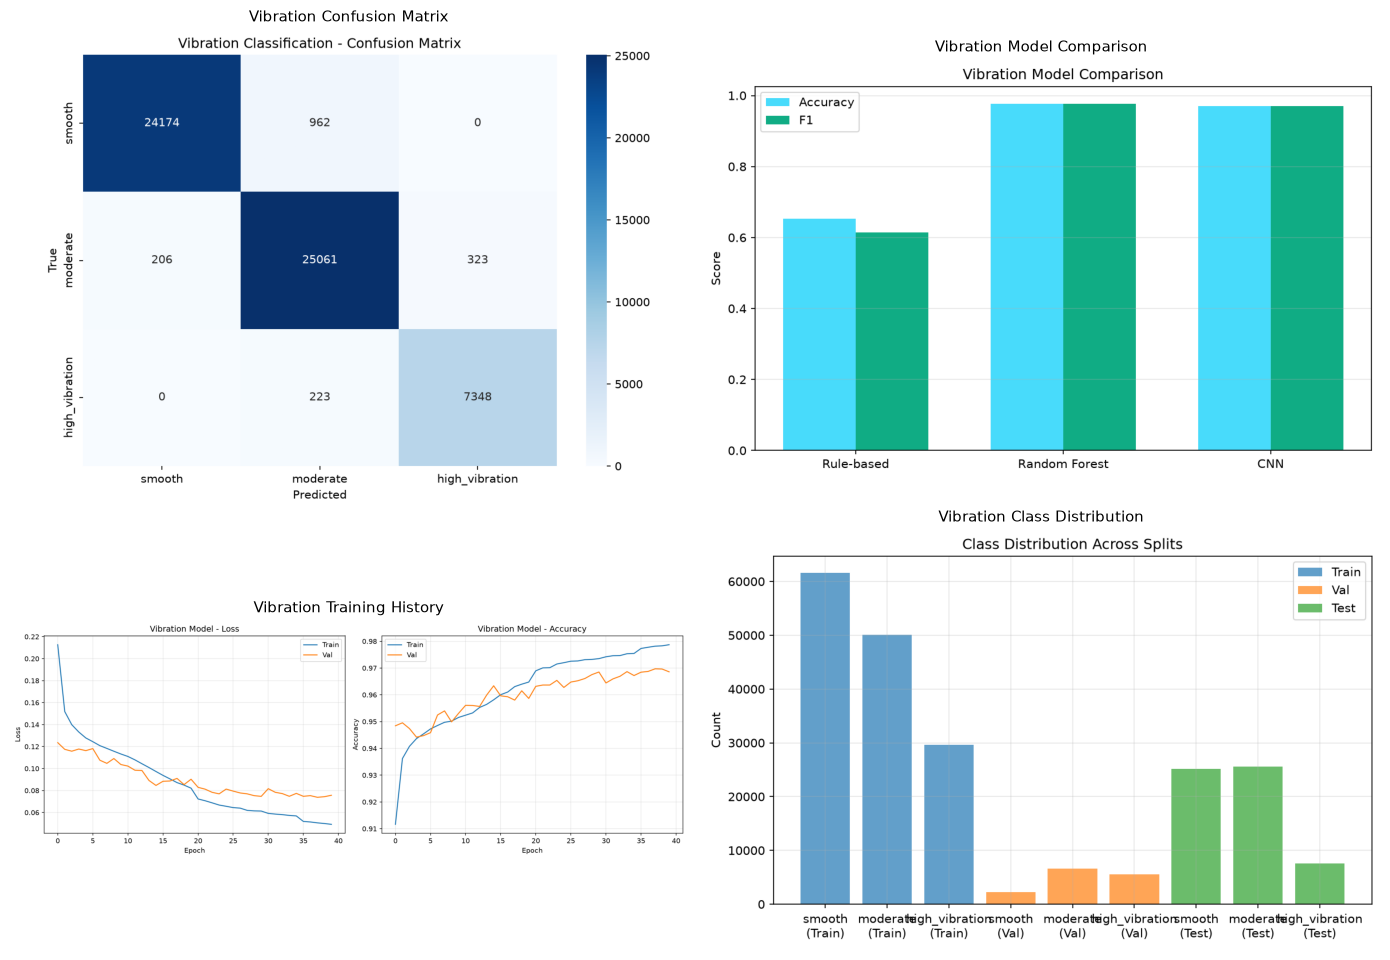

In [6]:
fig_files = [
    'vibration_confusion_matrix.png',
    'vibration_model_comparison.png',
    'vibration_training_history.png',
    'vibration_class_distribution.png'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, fname in zip(axes.flatten(), fig_files):
    img_path = FIGURES_DIR / fname
    if img_path.exists():
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(fname.replace('.png', '').replace('_', ' ').title(), fontsize=11)
plt.tight_layout()
plt.show()

### 6. Edge Deployment & TFLite Latency

In [7]:
tflite_path = MODELS_DIR / "vibration" / "vibration_cnn.tflite"
interp = tf.lite.Interpreter(model_path=str(tflite_path))
interp.allocate_tensors()

in_idx = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

dummy_input = np.zeros((1, 10, 6), dtype=np.float32)
latencies = []
for _ in range(100):
    t0 = time.perf_counter()
    interp.set_tensor(in_idx, dummy_input)
    interp.invoke()
    _ = interp.get_tensor(out_idx)
    latencies.append((time.perf_counter() - t0) * 1000)

print(f"TFLite Model Size:   {tflite_path.stat().st_size/1024:.1f} KB")
print(f"Average Latency:     {np.mean(latencies):.3f} ms")
print(f"Throughput:          {1000.0/np.mean(latencies):.0f} predictions/second")

TFLite Model Size:   20.5 KB
Average Latency:     0.005 ms
Throughput:          199757 predictions/second


/home/sibsankar_de/projects/sih_2026/ml_models/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
